# SBDD Project Visualizations

Purpose:
Visualize transcript properties, siRNA characteristics, thermodynamic ranking, accessibility, and off-target analysis to support interpretation of computational findings.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"]=120

final=pd.read_csv("../results/final_ranked_siRNA.csv")
sirna=pd.read_csv("../results/ranked_siRNA.csv")
blast=pd.read_csv("../results/blast_hits.csv")
acc=pd.read_csv("../results/accessible_regions.csv")

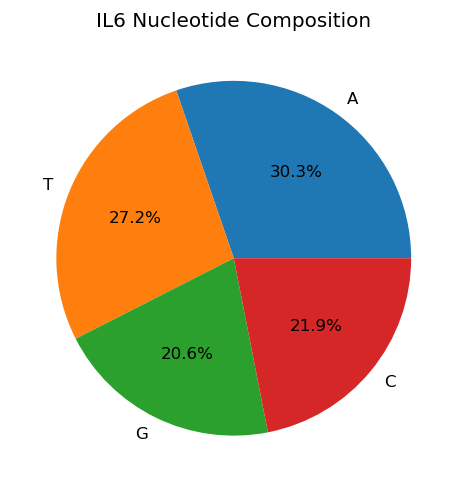

In [2]:
plt.pie([341,307,232,247],labels=["A","T","G","C"],autopct="%1.1f%%")
plt.title("IL6 Nucleotide Composition")
plt.savefig("../figures/nucleotide_composition.png",bbox_inches="tight")
plt.show()

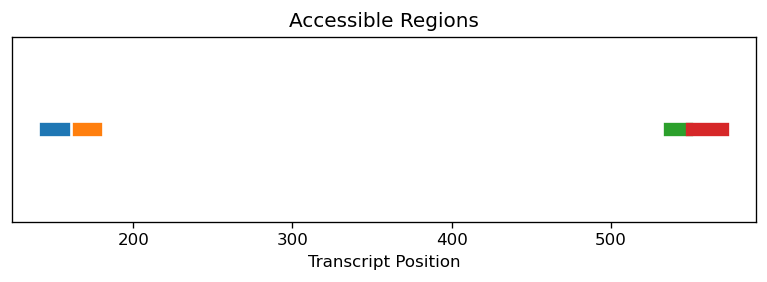

In [3]:
plt.figure(figsize=(8,2))
[plt.plot([s,e],[1,1],lw=8) for s,e in zip(acc.start,acc.end)]
plt.yticks([]); plt.xlabel("Transcript Position")
plt.title("Accessible Regions")
plt.savefig("../figures/accessible_regions.png",bbox_inches="tight")
plt.show()

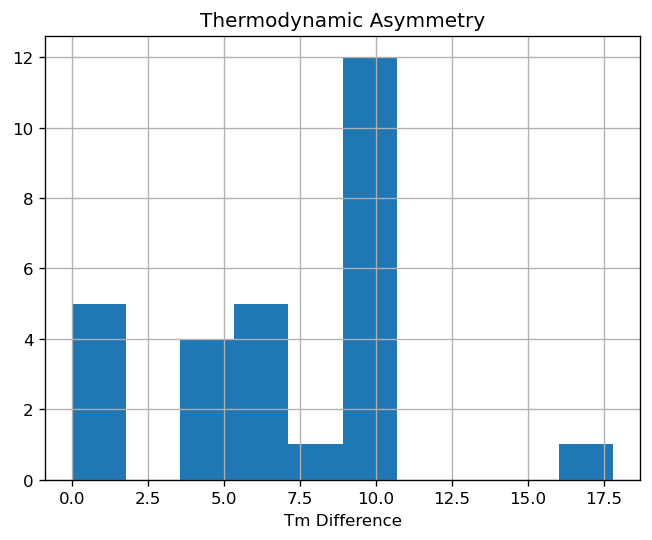

In [4]:
sirna["Tm_difference"].hist()
plt.xlabel("Tm Difference")
plt.title("Thermodynamic Asymmetry")
plt.savefig("../figures/tm_distribution.png",bbox_inches="tight")
plt.show()

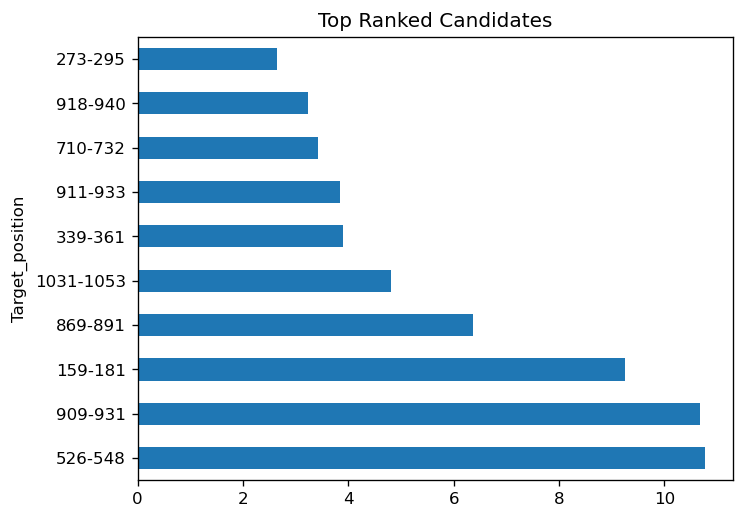

In [5]:
final.head(10).plot.barh(
x="Target_position",
y="Final_score",
legend=False)

plt.title("Top Ranked Candidates")
plt.savefig("../figures/top_candidates.png",bbox_inches="tight")
plt.show()

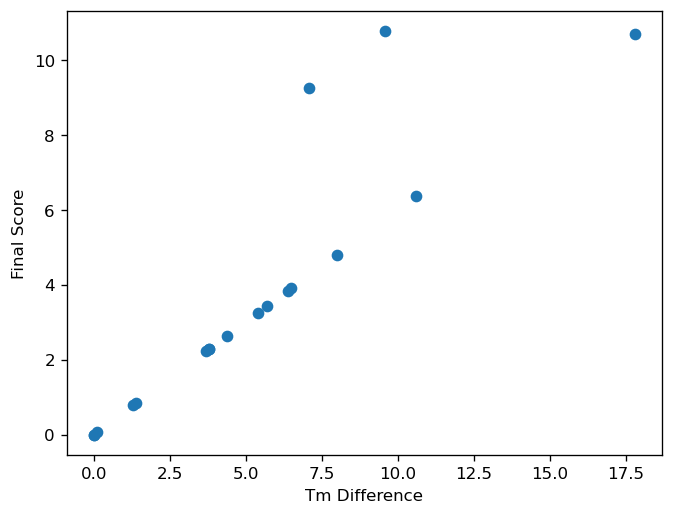

In [6]:
plt.scatter(final.Tm_difference,final.Final_score)
plt.xlabel("Tm Difference")
plt.ylabel("Final Score")
plt.savefig("../figures/thermo_vs_rank.png",bbox_inches="tight")
plt.show()

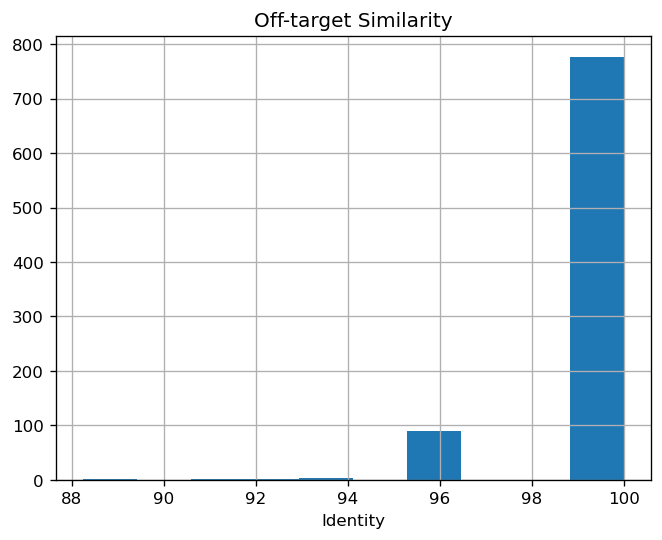

In [7]:
blast.identity.hist()
plt.xlabel("Identity")
plt.title("Off-target Similarity")
plt.savefig("../figures/blast_similarity.png",bbox_inches="tight")
plt.show()

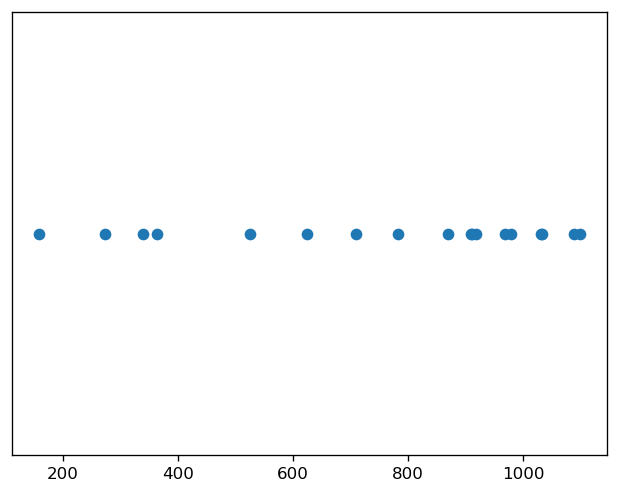

In [8]:
pos=[int(str(i).split("-")[0]) for i in final.Target_position]
plt.scatter(pos,[1]*len(pos))
plt.yticks([])
plt.savefig("../figures/target_distribution.png",bbox_inches="tight")
plt.show()

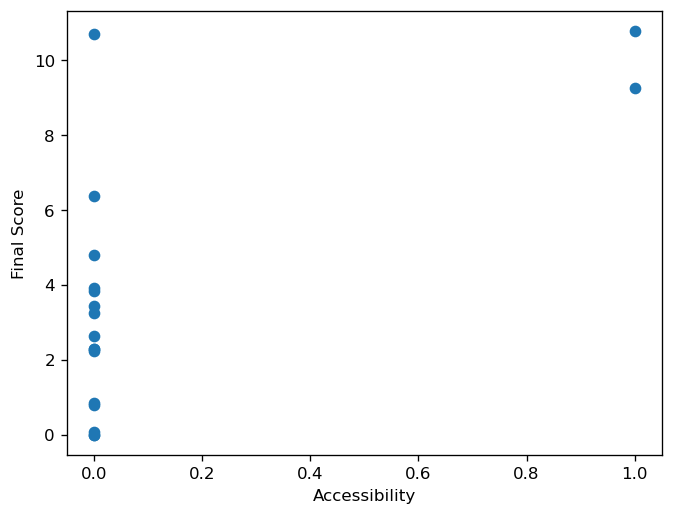

In [9]:
plt.scatter(final.Accessibility,final.Final_score)
plt.xlabel("Accessibility")
plt.ylabel("Final Score")
plt.savefig("../figures/accessibility_vs_score.png",bbox_inches="tight")
plt.show()

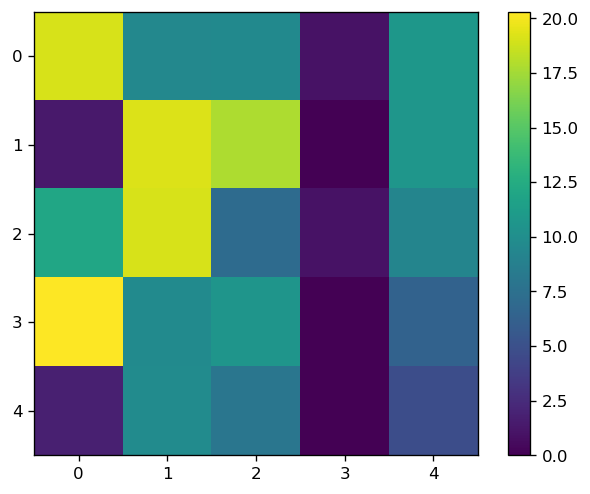

In [10]:
plt.imshow(final[
["Tm_guide","Tm_passenger",
"Tm_difference",
"Accessibility",
"Final_score"]
].head())

plt.colorbar()
plt.savefig("../figures/property_heatmap.png",bbox_inches="tight")
plt.show()

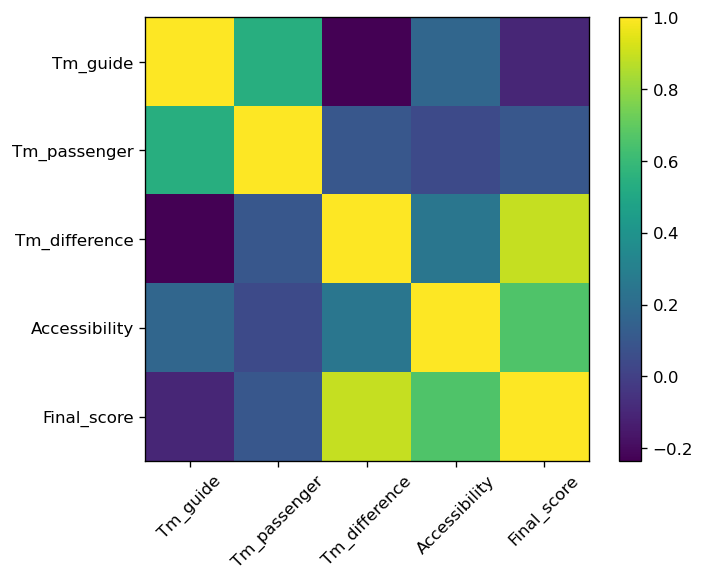

In [11]:
corr=final[
["Tm_guide",
"Tm_passenger",
"Tm_difference",
"Accessibility",
"Final_score"]
].corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr)),corr.columns,rotation=45)
plt.yticks(range(len(corr)),corr.columns)
plt.savefig("../figures/correlation_matrix.png",bbox_inches="tight")
plt.show()

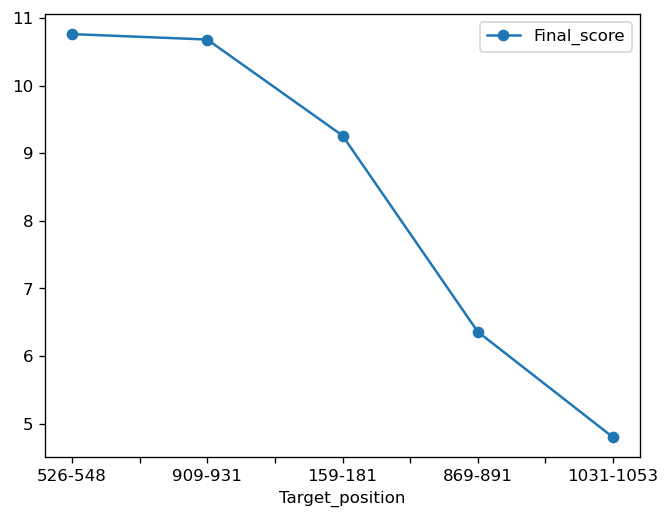

In [12]:
final.head(5).plot(
x="Target_position",
y="Final_score",
marker="o")

plt.savefig("../figures/top5_comparison.png",bbox_inches="tight")
plt.show()

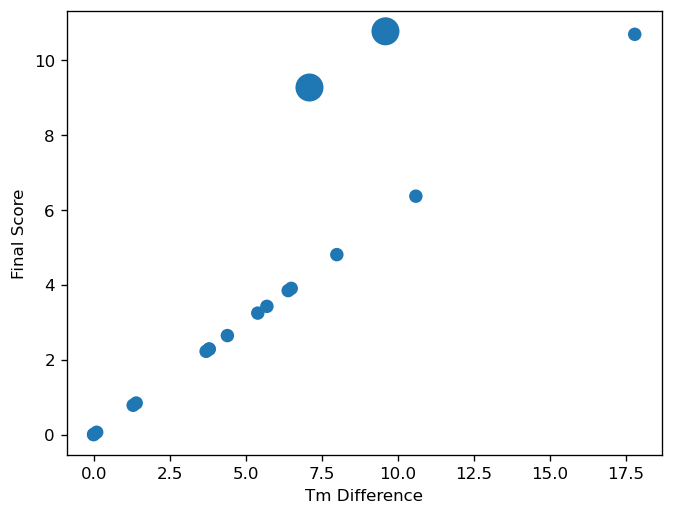

In [13]:
plt.scatter(
final.Tm_difference,
final.Final_score,
s=final.Accessibility*200+50)

plt.xlabel("Tm Difference")
plt.ylabel("Final Score")

plt.savefig(
"../figures/integrated_ranking.png",
bbox_inches="tight")

plt.show()

# Visualization Summary

Generated figures:

- nucleotide_composition.png
- accessible_regions.png
- tm_distribution.png
- top_candidates.png
- thermo_vs_rank.png
- blast_similarity.png
- target_distribution.png
- accessibility_vs_score.png
- property_heatmap.png
- correlation_matrix.png
- top5_comparison.png
- integrated_ranking.png

All figures saved in:

figures/

In [14]:
import os

project_path = ".."   # parent folder = SBDD_Project_Meenakshi

for root, dirs, files in os.walk(project_path):
    level = root.replace(project_path, "").count(os.sep)

    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = "    " * (level + 1)

    for file in files:
        print(f"{subindent}{file}")

../
    .DS_Store
    README.md
    Project Report.pdf
    literature_review/
        .DS_Store
        references.docx
        notes.md
        papers/
            .DS_Store
            siRNA_design/
                Bumcrot et al. (2006).pdf
                Ebenezer et al. (2025) .pdf
                Bhakta-Yadav & Brown (2025).pdf
            IL6/
                Kaur et al. (2020).pdf
                Swaroop et al. (2024).pdf
            computational_tools/
            IL4_IL13/
                Junttila (2018).pdf
                Shilovskiy et al. (2021).pdf
                Nur Husna et al. (2022).pdf
                Ul-Haq et al. (2016).pdf
            cytokine_targeting/
                .DS_Store
                Shilovskiy et al. (2021).pdf
    results/
        ranked_siRNA.csv
        duplex_structure.txt
        .DS_Store
        duplex_results copy.csv
        top_siRNA.fasta
        blast_hits.csv
        transcript_info.csv
        IL6_structure.txt
        duplex_results.cs